# 01 — Data Cleaning & Exploratory Analysis

This notebook loads the raw Telco customer data, checks quality, cleans numeric fields, and explores the main churn patterns.

## 1. Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/telco_churn_raw.csv')
print('Rows:', len(df))
print('Columns:', len(df.columns))
df.head()

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data quality checks

In [2]:
print(df.info())
print('\nDuplicate rows:', df.duplicated().sum())
print('Blank TotalCharges:', (df['TotalCharges'].astype(str).str.strip() == '').sum())
print('\nChurn distribution:')
print(df['Churn'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Clean TotalCharges

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing TotalCharges after conversion:', df['TotalCharges'].isna().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)


Missing TotalCharges after conversion: 11


## 4. Business KPIs

In [4]:
print(f"Overall churn rate: {df['Churn_flag'].mean():.2%}")
print(f"Average monthly charge: ${df['MonthlyCharges'].mean():.2f}")
print(f"Average tenure: {df['tenure'].mean():.1f} months")

Overall churn rate: 26.54%
Average monthly charge: $64.76
Average tenure: 32.4 months


## 5. Churn by contract

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn_flag, dtype: float64


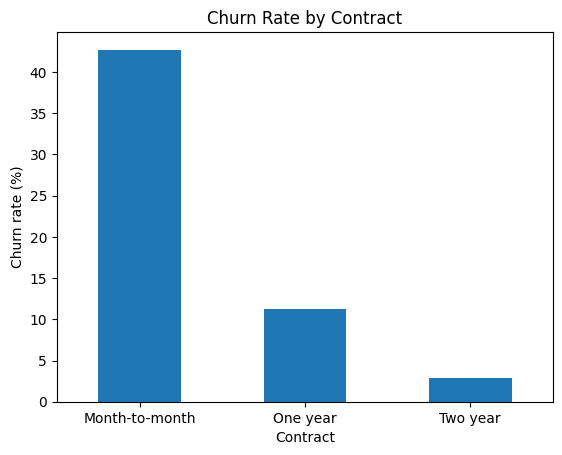

In [5]:
contract_churn = df.groupby('Contract')['Churn_flag'].mean().mul(100).sort_values(ascending=False)
print(contract_churn.round(2))
contract_churn.plot(kind='bar', title='Churn Rate by Contract')
plt.ylabel('Churn rate (%)')
plt.xticks(rotation=0)
plt.show()

## 6. Churn by tenure

tenure_bucket
0-6 months      52.94
7-12 months     35.89
13-24 months    28.71
25-48 months    20.39
49+ months       9.51
Name: Churn_flag, dtype: float64


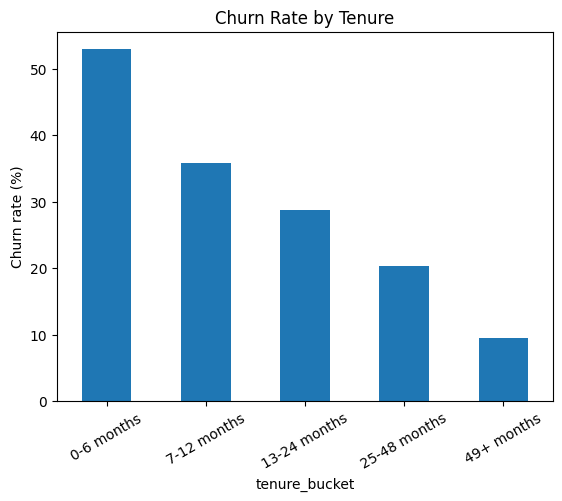

In [6]:
df['tenure_bucket'] = pd.cut(df['tenure'],[-1,6,12,24,48,100],labels=['0-6 months','7-12 months','13-24 months','25-48 months','49+ months'])
tenure_churn = df.groupby('tenure_bucket', observed=False)['Churn_flag'].mean().mul(100)
print(tenure_churn.round(2))
tenure_churn.plot(kind='bar', title='Churn Rate by Tenure')
plt.ylabel('Churn rate (%)')
plt.xticks(rotation=30)
plt.show()

## 7. Churn by other customer characteristics

In [7]:
for col in ['InternetService','PaymentMethod','TechSupport']:
    print('\n' + col)
    print(df.groupby(col)['Churn_flag'].mean().mul(100).round(2).sort_values(ascending=False))


InternetService


InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn_flag, dtype: float64

PaymentMethod
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn_flag, dtype: float64

TechSupport
TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn_flag, dtype: float64


## 8. Save the cleaned dataset

In [8]:
df.to_csv('../data/telco_churn_cleaned.csv', index=False)
print('Saved cleaned dataset.')

Saved cleaned dataset.
